# Multilingual Sentiment Analysis Demo

This notebook demonstrates a complete end-to-end multilingual sentiment analysis system for English, German, and Russian:

- Language-aware text preprocessing (`preprocess_ml.py`)
- TF-IDF feature extraction
- Calibrated Logistic Regression classifier
- Sentiment prediction with class probabilities

### Classes:
- Negative
- Neutral
- Positive

### Environment Setup

In [1]:
from pathlib import Path  # Path handling
import re  # Regex for lightweight language detection
import pandas as pd  # Data handling

# Project modules
from preprocess_ml import preprocess_text  # Text preprocessing function
from predict_model_ml import predict_sentiment, predict_proba, predict_batch_detailed  # Prediction functions


def infer_language(text):
    """Infer language from script/character patterns for demo diagnostics."""
    text = str(text).lower()
    if re.search(r"[а-яё]", text):
        return "russian"
    if re.search(r"[äöüß]", text):
        return "german"
    return "english"

### Load Dataset

In [2]:
BASE_DIR = Path().resolve().parents[0]  # Base directory
DATA_DIR = BASE_DIR / "data"  # Data directory

data_path = DATA_DIR / "train_ml.csv"  # Dataset path

df = pd.read_csv(data_path, encoding = "utf-8")  # Load dataset
df = df[["text", "sentiment"]].dropna().copy()  # Keep required columns and drop nulls
df["language"] = df["text"].apply(infer_language)  # Add inferred language for diagnostics

print("Dataset shape:", df.shape)
print("Language distribution:\n", df["language"].value_counts())
df.head()

Dataset shape: (497, 3)
Language distribution:
 language
english    259
russian    166
german      72
Name: count, dtype: int64


,text,sentiment,language
0,This plugin integrates perfectly with my workf...,positive,english
1,Время работы батареи среднее для этого ценовог...,neutral,russian
2,I really enjoy using this.,positive,english
3,It has been mostly reliable with minor issues.,neutral,english
4,It works as expected.,neutral,english


### Data Overview

C:\Users\Nikolai\AppData\Local\Temp\ipykernel_7992\2966473101.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


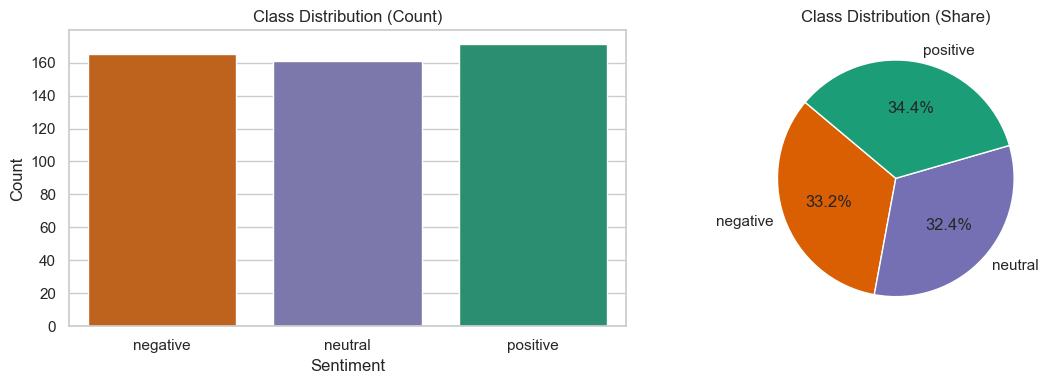

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

label_order = ["negative", "neutral", "positive"]

# CSV labels are already strings — no numeric mapping needed
label_series = df["sentiment"].astype(str).str.lower()
class_counts = label_series.value_counts().reindex(label_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    palette=["#d95f02", "#7570b3", "#1b9e77"],
    ax=axes[0]
    )
axes[0].set_title("Class Distribution (Count)")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")

axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct="%1.1f%%",
    colors=["#d95f02", "#7570b3", "#1b9e77"],
    startangle=140
    )
axes[1].set_title("Class Distribution (Share)")

plt.tight_layout()
plt.show()


In [4]:
# Display Class Distribution
print("Class Distribution:")
print(df["sentiment"].value_counts())

Class Distribution:
sentiment
positive    171
negative    165
neutral     161
Name: count, dtype: int64


### Preprocessing Demo (Multilingual)

In [5]:
samples = [
    ("I can't believe how amazing this product is!!!", "english"),
    ("Ich kann nicht glauben, wie gut dieses Produkt ist!!!", "german"),
    ("Не могу поверить, насколько классный этот продукт!!!", "russian"),
]

for text, lang in samples:
    processed_text = preprocess_text(text, language = lang)  # Preprocess using language-aware pipeline
    print(f"Language: {lang}")
    print(f"Original Text: {text}")
    print(f"Processed Text: {processed_text}\n")

Language: english
Original Text: I can't believe how amazing this product is!!!
Processed Text: can not believe amazing product

Language: german
Original Text: Ich kann nicht glauben, wie gut dieses Produkt ist!!!
Processed Text: nicht glauben gut Produkt

Language: russian
Original Text: Не могу поверить, насколько классный этот продукт!!!
Processed Text: не мочь поверить насколько классный продукт



### Model Training Explanation

The model was trained using `train_model_ml.py` with:

- Language-aware preprocessing from `preprocess_ml.py`
- TF-IDF vectorization (unigrams + bigrams)
- Logistic Regression baseline
- Calibrated probabilities (`CalibratedClassifierCV`)
- Stratified train/test split
- Label mapping:
  - negative -> 0
  - neutral -> 1
  - positive -> 2

Saved artifacts used in this notebook:
- `sentiment_model_ml.pkl`
- `vectorizer_ml.pkl`

### Single Text Prediction

In [6]:
text = "Das Update hat neue Fehler eingeführt und alles verlangsamt."  # Sample text for prediction
language = "german"  # Language for preprocessing/inference

prediction = predict_sentiment(text, language = language)  # Predict sentiment
probabilities = predict_proba(text, language = language)  # Get prediction probabilities

print(f"Text: {text}")
print(f"Language: {language}")
print(f"Prediction: {prediction}")
print("Probabilities:")
for label, score in probabilities.items():
    print(f"\t{label}: {score:.3f}")

Text: Das Update hat neue Fehler eingeführt und alles verlangsamt.
Language: german
Prediction: neutral
Probabilities:
	negative: 0.360
	neutral: 0.262
	positive: 0.378


### Batch Text Prediction

In [7]:
# Sample multilingual texts with explicit language tags
examples = [
    {"text": "I absolutely loved this! Best experience ever.", "language": "english"},
    {"text": "Das ist das Geld nicht wert.", "language": "german"},
    {"text": "Все работает плавно.", "language": "russian"},
    {"text": "The checkout process worked after one retry.", "language": "english"},
    {"text": "Die Benutzeroberfläche ist überladen und frustrierend.", "language": "german"},
]

results = []
for item in examples:
    text = item["text"]
    lang = item["language"]
    scores = predict_proba(text, language = lang)  # Get per-label probabilities
    pred = predict_sentiment(text, language = lang)  # Get final sentiment label
    results.append({
        "text": text,
        "language": lang,
        "prediction": pred,
        "probabilities": scores,
    })

for item in results:
    print(f"\nLanguage: {item['language']}")
    print(f"Text: {item['text']}")
    print(f"Prediction: {item['prediction']}")
    print("Probabilities:")
    for label, score in item["probabilities"].items():
        print(f"\t{label}: {score:.3f}")


Language: english
Text: I absolutely loved this! Best experience ever.
Prediction: positive
Probabilities:
	negative: 0.338
	neutral: 0.163
	positive: 0.499

Language: german
Text: Das ist das Geld nicht wert.
Prediction: negative
Probabilities:
	negative: 0.617
	neutral: 0.206
	positive: 0.177

Language: russian
Text: Все работает плавно.
Prediction: neutral
Probabilities:
	negative: 0.360
	neutral: 0.262
	positive: 0.378

Language: english
Text: The checkout process worked after one retry.
Prediction: neutral
Probabilities:
	negative: 0.181
	neutral: 0.666
	positive: 0.152

Language: german
Text: Die Benutzeroberfläche ist überladen und frustrierend.
Prediction: negative
Probabilities:
	negative: 0.511
	neutral: 0.211
	positive: 0.278


### Classifier Visual Diagnostics

These charts summarize batch predictions and confidence behavior across multilingual inputs.

Note: the confusion matrix uses current notebook data and inferred language tags for quick diagnostics, not a strict holdout benchmark.

C:\Users\Nikolai\AppData\Local\Temp\ipykernel_7992\1314693033.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


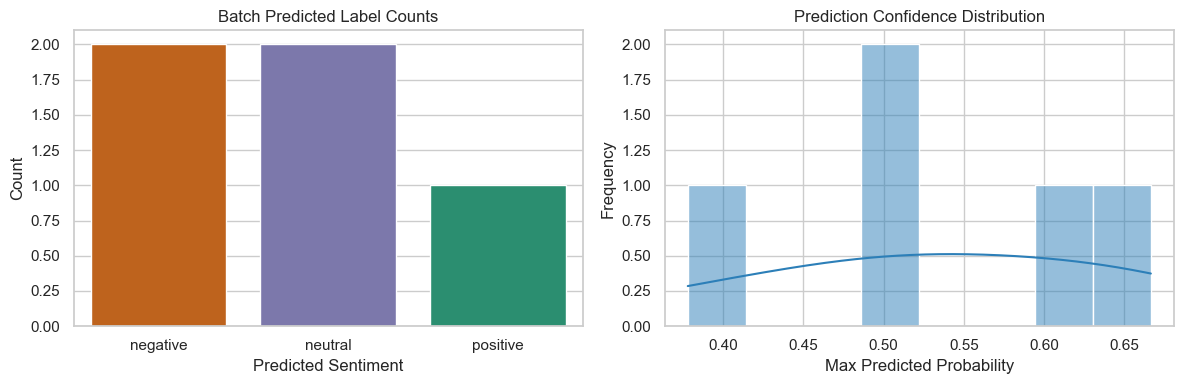

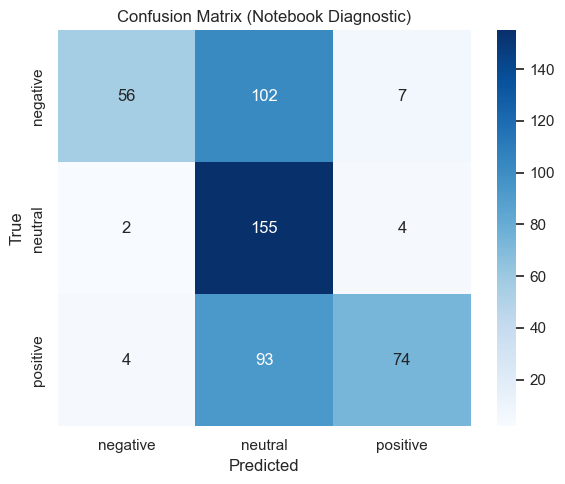

Classification Report (Notebook Diagnostic):
              precision    recall  f1-score   support

    negative       0.90      0.34      0.49       165
     neutral       0.44      0.96      0.61       161
    positive       0.87      0.43      0.58       171

    accuracy                           0.57       497
   macro avg       0.74      0.58      0.56       497
weighted avg       0.74      0.57      0.56       497



In [8]:
from sklearn.metrics import confusion_matrix, classification_report

label_order = ["negative", "neutral", "positive"]

# 1) Batch prediction summary charts
results_df = pd.DataFrame(results)
proba_df = pd.DataFrame(results_df["probabilities"].tolist())

pred_counts = results_df["prediction"].value_counts().reindex(label_order, fill_value=0)
confidence = proba_df.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    x=pred_counts.index,
    y=pred_counts.values,
    palette=["#d95f02", "#7570b3", "#1b9e77"],
    ax=axes[0],
)
axes[0].set_title("Batch Predicted Label Counts")
axes[0].set_xlabel("Predicted Sentiment")
axes[0].set_ylabel("Count")

sns.histplot(confidence, bins=8, kde=True, color="#2c7fb8", ax=axes[1])
axes[1].set_title("Prediction Confidence Distribution")
axes[1].set_xlabel("Max Predicted Probability")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# 2) Quick confusion matrix on notebook dataset
eval_df = df[["text", "sentiment", "language"]].dropna().copy()
true_labels = eval_df["sentiment"].astype(str).str.lower()
valid_mask = true_labels.isin(label_order)
eval_df = eval_df[valid_mask]
true_labels = true_labels[valid_mask]

pred_labels = eval_df.apply(
    lambda row: predict_sentiment(row["text"], language = row["language"]),
    axis=1,
 )
cm = confusion_matrix(true_labels, pred_labels, labels=label_order)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_order,
    yticklabels=label_order,
 )
plt.title("Confusion Matrix (Notebook Diagnostic)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

print("Classification Report (Notebook Diagnostic):")
print(classification_report(true_labels, pred_labels, labels=label_order, zero_division=0))

### Clean Table Output


In [9]:
pd.DataFrame(results)

,text,language,prediction,probabilities
0,I absolutely loved this! Best experience ever.,english,positive,"{'negative': 0.3382635681946182, 'neutral': 0...."
1,Das ist das Geld nicht wert.,german,negative,"{'negative': 0.6170150627919796, 'neutral': 0...."
2,Все работает плавно.,russian,neutral,"{'negative': 0.3598582047301571, 'neutral': 0...."
3,The checkout process worked after one retry.,english,neutral,"{'negative': 0.18128586415413972, 'neutral': 0..."
4,Die Benutzeroberfläche ist überladen und frust...,german,negative,"{'negative': 0.5110805886488093, 'neutral': 0...."


### Interactive Demo

In [10]:
user_input = input("Enter text to analyze sentiment: ")  # Get user input text
user_language = input("Language (english/german/russian): ").strip().lower()  # Get language input
if user_language not in {"english", "german", "russian"}:
    user_language = infer_language(user_input)  # Fallback to lightweight language detection

user_prediction = predict_sentiment(user_input, language = user_language)  # Predict final sentiment
user_probabilities = predict_proba(user_input, language = user_language)  # Predict probability scores

print(f"Language: {user_language}")
print(f"Predicted Sentiment: {user_prediction}")
print("Probabilities:")
for label, score in user_probabilities.items():
    print(f"\t{label}: {score:.3f}")

Language: german
Predicted Sentiment: neutral
Probabilities:
	negative: 0.360
	neutral: 0.262
	positive: 0.378
